**Imports**

In [ ]:
# =============================================================================
# DEEP LEARNING INDABA — Building Neural Networks from First Principles
# Interactive Colab Notebook
# =============================================================================

# ── CELL 1: Setup & Imports ──────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

print("="*55)
print("  Deep Learning IndabaX")
print("="*55)
print("Everything loaded. Let's build a neural network from scratch!\n")


  Deep Learning IndabaX
Everything loaded. Let's build a neural network from scratch!



**SECTION 1: THE SINGLE NEURON**

Skin Lesion Classification Example:
  Patterns P:
[[0 1]
 [0 1]]
  Targets  T: [[1 0]]
  Net input N = [[ 1. -1.]]
  Activations A = hardlim(N): [[1. 0.]]
  Correct? True


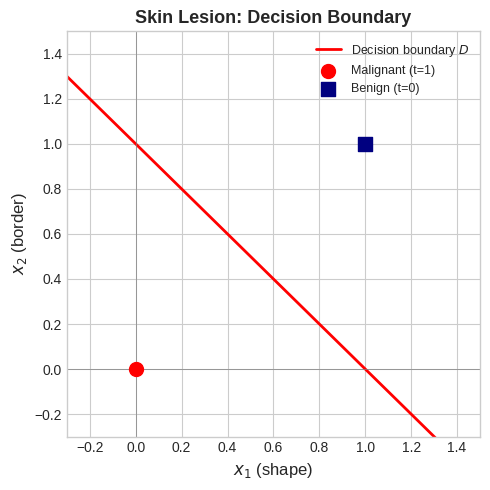

In [ ]:

# ── CELL 2: The Single Neuron ─────────────────────────────────────────────────
"""
A single neuron computes:
    n = W * p + b       (linear combination)
    a = f(n)            (activation / transfer function)

where:
  p  = input pattern (column vector)
  W  = weight matrix (row vector for one neuron)
  b  = bias scalar
  f  = transfer function (hardlim, tansig, logsig, etc.)
"""

def hardlim(n):
    """Step function: output 1 if n >= 0, else 0."""
    return (n >= 0).astype(float)

# ── MELANOMA EXAMPLE ──────────────────────────────────────────
# Classify: malignant (t=1) vs benign (t=0)
# Features: x1 = symmetric (1) / asymmetric (0)
#           x2 = regular border (1) / irregular (0)
#
# malignant pattern: p = [0, 0]  ->  t = 1
# benign pattern:   p = [1, 1]  ->  t = 0

# ── INPUT DATA ───────────────────────────────────────────────────────────────
# Two patterns as COLUMNS of P. Each column is one input [x1, x2].
# melanoma: [0, 0]  (asymmetric, irregular border)
# mole:     [1, 1]  (symmetric, regular border)

P = np.array([[0, 1],
              [0, 1]])   # shape: (2, 2) : 2 features, 2 patterns
T = np.array([[1, 0]])   # targets: melignant=1, benign=0

# ── WEIGHTS AND BIAS (chosen geometrically — see slide) ──────────────────────
W = np.array([[-1, -1]])  # shape: (1, 2) : one neuron, two inputs
b = 1.0

# ── Step 1: compute the NET INPUT ────────────────────────────────────────────
# @ is NumPy matrix multiply. W has the shape (1,2), P has the shape (2,2), result N must have shape (1,2).
# Then we add the scalar bias b to every element.
N = W @ P + b

# ── Step 2: compute the ACTIVATION ───────────────────────────────────────────
# Pass N through the step function: output 1 where n >= 0, else 0.
A = hardlim(N)

print("Skin Lesion Classification Example:")
print(f"  Patterns P:\n{P}")
print(f"  Targets  T: {T}")
print(f"  Net input N = {N}")
print(f"  Activations A = hardlim(N): {A}")
print(f"  Correct? {np.array_equal(A, T)}")

# Visualise decision boundary: W*p + b = 0
#   -x1 - x2 + 1 = 0  =>  x2 = 1 - x1
fig, ax = plt.subplots(figsize=(5, 5))
x_vals = np.linspace(-0.3, 1.5, 100)
ax.plot(x_vals, 1 - x_vals, 'r-', lw=2, label='Decision boundary $D$')
ax.scatter([0], [0], s=100, c='red',   marker='o', zorder=5, label='Malignant (t=1)')
ax.scatter([1], [1], s=100, c='navy', marker='s', zorder=5, label='Benign (t=0)')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('$x_1$ (shape)', fontsize=12)
ax.set_ylabel('$x_2$ (border)', fontsize=12)
ax.set_title('Skin Lesion: Decision Boundary', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.set_xlim(-0.3, 1.5); ax.set_ylim(-0.3, 1.5)
plt.tight_layout()
plt.savefig("decision_boundary_1neuron.png", dpi=130, bbox_inches='tight')
plt.show()




**SECTION 2: ACTIVATION FUNCTIONS**

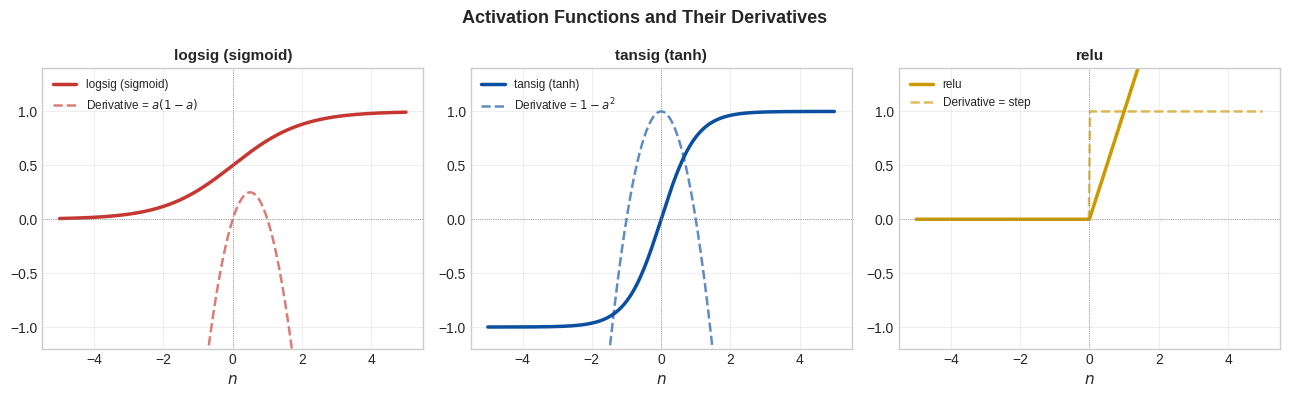

Key insight: sigmoid derivative is at most 0.25 — this leads to
   vanishing gradients in deep networks. ReLU avoids this.



In [ ]:
# ── CELL 3: Activation Functions & Their Derivatives ─────────────────────────
"""
We need differentiable transfer functions to trace errors back through the network.
The step function hardlim is NOT differentiable — small weight changes cause
massive output jumps.

Key functions and their derivatives (dot notation from Burton):
  logsig: f(n) = 1/(1+exp(-n))      f'(n) = a(1-a)
  tansig: f(n) = tanh(n)             f'(n) = 1 - a^2
  relu:   f(n) = max(0, n)           f'(n) = 1 if n > 0 else 0
  purelin: f(n) = n                  f'(n) = 1
"""

def logsig(n):
    """Sigmoid: maps n -> (0, 1). Used at output for binary classification."""
    return 1.0 / (1.0 + np.exp(-np.clip(n, -500, 500)))

def logsig_deriv(a):
    """Derivative of logsig in terms of activation a: a*(1-a)."""
    return a * (1.0 - a)

def tansig(n):
    """Tanh: maps n -> (-1, 1). Good for hidden layers."""
    return np.tanh(n)

def tansig_deriv(a):
    """Derivative of tansig in terms of activation a: 1 - a^2."""
    return 1.0 - a**2

def relu(n):
    """ReLU: max(0, n). Fast, avoids vanishing gradients."""
    return np.maximum(0, n)

def relu_deriv(n):
    """Derivative of ReLU in terms of n: 1 if n>0 else 0."""
    return (n > 0).astype(float)

def purelin(n):
    """Linear (identity) transfer function. Used in regression output."""
    return n

def purelin_deriv(a):
    """Derivative of purelin: always 1."""
    return np.ones_like(a)

def diag_deriv(fn_name, a, n=None):
    """
    Returns the diagonal derivative matrix D = diag(f'(n))
    expressed in terms of activation a (where possible).
    """
    if fn_name == "logsig":
        fdot = logsig_deriv(a)
    elif fn_name == "tansig":
        fdot = tansig_deriv(a)
    elif fn_name == "purelin":
        fdot = purelin_deriv(a)
    elif fn_name == "relu":
        fdot = relu_deriv(n if n is not None else a)
    else:
        raise ValueError(f"Unknown function: {fn_name}")
    # Average across batch (columns) for diagonal
    return np.diag(np.mean(fdot, axis=1)) if fdot.ndim > 1 else np.diag(fdot)

# Visualise
n_vals = np.linspace(-5, 5, 300)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Activation Functions and Their Derivatives", fontsize=13, fontweight='bold')

configs = [
    ("logsig (sigmoid)", logsig, logsig_deriv, "Derivative = $a(1-a)$", "#C63732"),
    ("tansig (tanh)",    tansig, tansig_deriv, "Derivative = $1-a^2$",  "#0A4FA0"),
    ("relu",             relu,   lambda n: (n>0).astype(float),
                                              "Derivative = step",      "#CC9900"),
]

for ax, (name, fn, dfn, dlabel, color) in zip(axes, configs):
    a_vals = fn(n_vals)
    ax.plot(n_vals, a_vals,        color=color, lw=2.5, label=f'{name}')
    ax.plot(n_vals, dfn(n_vals),   color=color, lw=1.8, ls='--', alpha=0.65,
            label=dlabel)
    ax.axhline(0, color='gray', lw=0.6, ls=':')
    ax.axvline(0, color='gray', lw=0.6, ls=':')
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8.5)
    ax.set_xlabel('$n$', fontsize=11)
    ax.set_ylim(-1.2, 1.4)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("activations.png", dpi=130, bbox_inches='tight')
plt.show()

print("Key insight: sigmoid derivative is at most 0.25 — this leads to")
print("   vanishing gradients in deep networks. ReLU avoids this.\n")


**SECTION 3 & 4: MLP ARCHITECTURE + FORWARD PROPAGATION**

In [ ]:

# ── CELL 4: Initialise Network Parameters ────────────────────────────────────
"""
Network architecture: (r, s1, s2, ..., sM)
  r  = input dimension
  sm = number of neurons in layer m

Each layer m has:
  W^m : weight matrix of shape (s_m, s_{m-1})
  b^m : bias vector of shape (s_m, 1)
"""

def init_params(layer_dims, scale=1.0):
    """
    Randomly initialise weights and biases.
    scale=1.0 ensures neurons start in the non-linear regime of tansig,
    which is critical for learning non-linear boundaries.
    """
    params = {}
    M = len(layer_dims) - 1

    for m in range(1, M + 1):
        s_m  = layer_dims[m]
        s_m1 = layer_dims[m - 1]
        # Random weights: shape (s_m, s_m1)
        params[f"W{m}"] = np.random.randn(s_m, s_m1) * scale
        # Zero biases: shape (s_m, 1)
        params[f"b{m}"] = np.zeros((s_m, 1))

    return params

# Test
print("Network: [2 → 8 → 8 → 1]")
params_test = init_params([2, 8, 8, 1])
M_test = len(params_test) // 2
for m in range(1, M_test + 1):
    W, b = params_test[f"W{m}"], params_test[f"b{m}"]
    print(f"  Layer {m}: W{m}.shape={W.shape},  b{m}.shape={b.shape}")



Network: [2 → 8 → 8 → 1]
  Layer 1: W1.shape=(8, 2),  b1.shape=(8, 1)
  Layer 2: W2.shape=(8, 8),  b2.shape=(8, 1)
  Layer 3: W3.shape=(1, 8),  b3.shape=(1, 1)


In [ ]:
# ── CELL 5: Forward Propagation ──────────────────────────────────────────────
"""
Forward pass for layer m:
    N^m = W^m * A^{m-1} + b^m      (linear step)
    A^m = f^m(N^m)                  (activation step)

We store N^m and A^m in a 'cache' for use in backpropagation.
A^0 = P (the input pattern matrix).
"""

HIDDEN_FN   = "tansig"   # hidden layer activation
OUTPUT_FN   = "logsig"   # output layer activation (binary classification)

def activate(fn_name, n):
    """Apply named activation function."""
    if fn_name == "tansig":   return tansig(n)
    if fn_name == "logsig":   return logsig(n)
    if fn_name == "relu":     return relu(n)
    if fn_name == "purelin":  return purelin(n)
    raise ValueError(fn_name)

def forward(P, params, hidden_fn=HIDDEN_FN, output_fn=OUTPUT_FN):
    """
    Full forward pass through the network.

    For each layer m = 1 ... M:
        N^m = W^m @ A^{m-1} + b^m    (linear step)
        A^m = f^m(N^m)                (activation step)

    A^0 = P (the input).
    Everything is cached for backpropagation.

    P:       input batch,   shape (r, q)
    params:  dict of Wm, bm

    Returns: AM (output activations), cache (all Nm, Am for backprop)
    """
    cache = {"A0": P}   # store input as A^0
    A = P
    M = len(params) // 2

    for m in range(1, M + 1):
        W  = params[f"W{m}"]
        b  = params[f"b{m}"]
        fn = output_fn if m == M else hidden_fn

        # ── Step 1: linear step ───────────────────────────────────────────────────
        # N = W @ A + b
        # Matrix-multiply the weight matrix by the previous activations, add bias.
        N = W @ A + b                          # shape: (s_m, q)

        # ── Step 2: activation step ───────────────────────────────────────────
        # Apply the transfer function (tansig for hidden, logsig for output).
        A = activate(fn, N)

        # ── Step 3: cache everything ──────────────────────────────────────────
        # Backpropagation will retrieve these — do not skip this step.
        cache[f"N{m}"] = N
        cache[f"A{m}"] = A

    return A, cache

# Shape verification
print("\nForward pass shape check:")
P_dummy = np.random.randn(2, 10)   # 2 features, 10 examples
AM, cache_test = forward(P_dummy, params_test)
M_test = len(params_test) // 2
for m in range(1, M_test + 1):
    print(f"  N{m}.shape = {cache_test[f'N{m}'].shape}, "
          f"A{m}.shape = {cache_test[f'A{m}'].shape}")
print(f"  AM.shape = {AM.shape} , should be (1, 10)")




Forward pass shape check:
  N1.shape = (8, 10), A1.shape = (8, 10)
  N2.shape = (8, 10), A2.shape = (8, 10)
  N3.shape = (1, 10), A3.shape = (1, 10)
  AM.shape = (1, 10) , should be (1, 10)


In [ ]:
# =============================================================================
# SECTION 5: LOSS FUNCTIONS
# =============================================================================

# ── CELL 6: Loss Functions ───────────────────────────────────────────────────

def mse_loss(AM, T):
    """
    Mean Square Error:  MSE = (1/q) * sum( (T - AM)^2 )
    e = T - AM  is the error vector.
    Returns (loss_value, error_vector).
    """
    # ── Step 1: error vector ─────────────────────────────────────────────────
    # e = T - AM : elementwise subtraction, target minus prediction.
    e = T - AM

    # ── Step 2: mean square error ─────────────────────────────────────────────
    # Square each error (so negatives and positives do not cancel),
    # then take the mean across all examples.
    loss = float(np.mean(e**2))

    return loss, e


def bce_loss(AM, T):
    """
    Binary Cross-Entropy:
      L = -(1/q) * sum[ T*log(AM) + (1-T)*log(1-AM) ]
    Returns (loss_value, error_vector).
    AM: predicted probabilities in (0,1)
    T:  true binary labels {0,1}
    """
    # eps prevents log(0)
    eps = 1e-8
    q   = T.shape[1]

    # ── Binary Cross-Entropy formula ─────────────────────────────────────────
    # For each example: -[ t*log(a) + (1-t)*log(1-a) ]
    # eps prevents log(0) which would give -infinity.
    loss = -(1/q) * np.sum(T * np.log(AM + eps) + (1 - T) * np.log(1 - AM + eps))

    # Error vector: same definition as MSE.
    e = T - AM

    return float(loss), e


print(" Good predictions should have LOWER loss.\n")


 Good predictions should have LOWER loss.



**SECTION 6: BACKPROPAGATION**

In [ ]:

# ── CELL 7: The Sensitivity Vector & Backward Pass ──────────────────────────


# ── CELL 7: The Sensitivity Vector & Backward Pass ───────────────────────────
"""
Backpropagation (Burton, Ch. 4, Theorem 4.4.1 & 4.4.2):

SENSITIVITY of layer m:
    S^m = dE / dN^m

COMPUTATION (backwards from layer M):
    Output layer:  S^M = -2 * f'(A^M) * e            (elementwise multiply)
    Hidden layers: S^m = f'(A^m) * (W^{m+1})^T S^{m+1}  (elementwise)

WEIGHT UPDATES (averaged over batch size q):
    W^m <- W^m - alpha * (1/q) * S^m * (A^{m-1})^T
    b^m <- b^m - alpha * (1/q) * sum(S^m, axis=1)
"""

def backward(T, params, cache, hidden_fn=HIDDEN_FN, output_fn=OUTPUT_FN):
    grads = {}
    M  = len(params) // 2
    AM = cache[f"A{M}"]
    e  = T - AM
    q  = AM.shape[1]

    # Output layer: f'(a) for logsig = a*(1-a) — elementwise, shape (s_M, q)
    fdot_M = AM * (1.0 - AM)
    S = -2.0 * fdot_M * e          # elementwise multiply

    for m in reversed(range(1, M + 1)):
        Am1 = cache[f"A{m-1}"]
        W   = params[f"W{m}"]

        # Gradients — averaged over batch
        grads[f"dW{m}"] = (S @ Am1.T) / q
        grads[f"db{m}"] = np.sum(S, axis=1, keepdims=True) / q

        # Propagate sensitivity to previous layer
        if m > 1:
            Am_prev   = cache[f"A{m-1}"]
            fdot_prev = 1.0 - Am_prev**2   # tansig: f'(a) = 1 - a^2
            S = fdot_prev * (W.T @ S)      # elementwise multiply

    return grads

# Shape verification
print("Backward pass shape check:")
T_dummy    = (np.random.rand(1, 10) > 0.5).astype(float)
grads_test = backward(T_dummy, params_test, cache_test)
for m in range(1, M_test + 1):
    wshape = params_test[f"W{m}"].shape
    gshape = grads_test[f"dW{m}"].shape
    match  = "✅" if wshape == gshape else "❌"
    print(f"  {match} dW{m}.shape={gshape}  (should match W{m}.shape={wshape})")



Backward pass shape check:
  ✅ dW1.shape=(8, 2)  (should match W1.shape=(8, 2))
  ✅ dW2.shape=(8, 8)  (should match W2.shape=(8, 8))
  ✅ dW3.shape=(1, 8)  (should match W3.shape=(1, 8))


**Numerical Gradient Check validation**

In [ ]:
# ── CELL 8) ───────────────────────────
# ── CELL 8: Numerical Gradient Verification ──────────────────────────────────
"""
Verify backward() by comparing analytical gradients to finite differences:
    dE/dW_ij ≈ [E(W + eps) - E(W - eps)] / (2*eps)
Agreement to ~1e-7 confirms the chain rule was applied correctly.
"""

def numerical_grad_check(P, T, params, epsilon=1e-5):
    print("\n🔬 Numerical Gradient Verification:")
    for key in ["W1", "b1"]:
        W_orig   = params[key].copy()
        grad_num = np.zeros_like(W_orig)
        AM, cache_c = forward(P, params)
        grads_an = backward(T, params, cache_c)

        for idx in np.ndindex(W_orig.shape):
            params[key][idx] += epsilon
            AM_plus, _   = forward(P, params)
            loss_plus, _ = mse_loss(AM_plus, T)

            params[key][idx] -= 2 * epsilon
            AM_minus, _   = forward(P, params)
            loss_minus, _ = mse_loss(AM_minus, T)

            grad_num[idx]    = (loss_plus - loss_minus) / (2 * epsilon)
            params[key][idx] = W_orig[idx]

        diff   = np.max(np.abs(grads_an[f"d{key}"] - grad_num))
        status = "✅ PASS" if diff < 1e-4 else "❌ FAIL"
        print(f"  {key}: max|analytical - numerical| = {diff:.2e}  {status}")

params_check = init_params([2, 3, 1], scale=0.1)
np.random.seed(7)
P_check  = np.random.randn(2, 5)
T_check2 = (np.random.rand(1, 5) > 0.5).astype(float)
numerical_grad_check(P_check, T_check2, params_check)



🔬 Numerical Gradient Verification:
  W1: max|analytical - numerical| = 3.70e-12  ✅ PASS
  b1: max|analytical - numerical| = 3.49e-12  ✅ PASS


**SECTION 7: GRADIENT DESCENT & FULL TRAINING LOOP**

In [ ]:

# ── CELL 9: Full Training Loop ──────────────────────────────────────────────


def train(P, T, layer_dims, lr=0.05, num_epochs=2000,
          loss_fn="mse", print_every=200, seed=42):
    np.random.seed(seed)
    params  = init_params(layer_dims)
    history = []

    for epoch in range(num_epochs):
        AL, cache = forward(P, params)
        if loss_fn == "bce":
            loss, e = bce_loss(AL, T)
        else:
            loss, e = mse_loss(AL, T)
        history.append(loss)

        grads = backward(T, params, cache)
        M = len(params) // 2
        for m in range(1, M + 1):
            params[f"W{m}"] -= lr * grads[f"dW{m}"]
            params[f"b{m}"] -= lr * grads[f"db{m}"]

        if epoch % print_every == 0:
            print(f"  Epoch {epoch:4d}  |  MSE = {loss:.6f}")

    return params, history

def predict(P, params):
    AL, _ = forward(P, params)
    return (AL >= 0.5).astype(float)

def accuracy(P, T, params):
    return float(np.mean(predict(P, params) == T)) * 100


Learning Rate Experiment:
  Epoch    0  |  MSE = 0.255025
  Epoch    0  |  MSE = 0.255025
  Epoch    0  |  MSE = 0.255025
  Epoch    0  |  MSE = 0.255025


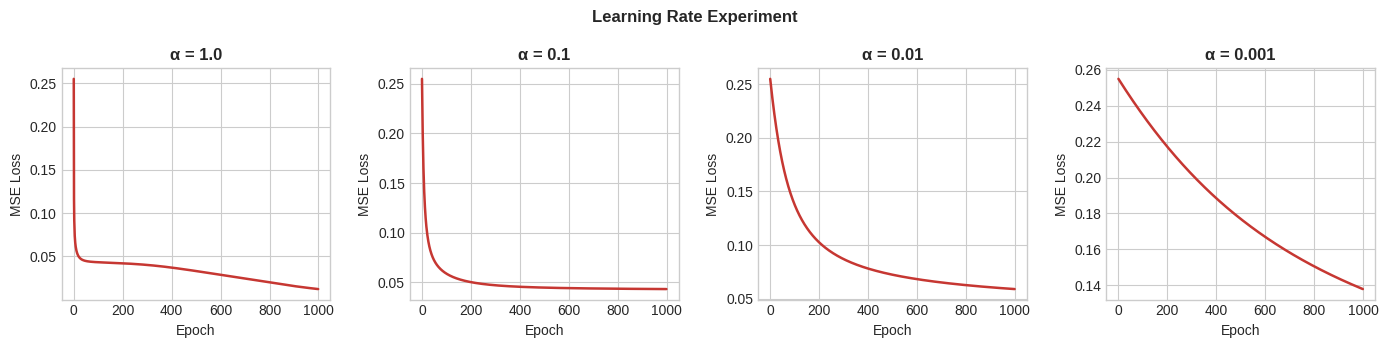


  α=1.0 converges fast but may overshoot.
  α=0.1 is the sweet spot — steady smooth descent.
  α=0.01 converges but slowly.
  α=0.001 barely moves — impractically slow.


In [ ]:
# ── CELL 10: Learning Rate Experiment ────────────────────────────────────────
# Generate a small 2D classification dataset

np.random.seed(1)
n_pts = 200
theta = np.linspace(0, np.pi, n_pts // 2)
X1_lr = np.c_[np.cos(theta), np.sin(theta)]    + np.random.randn(n_pts//2, 2)*0.15
X2_lr = np.c_[1-np.cos(theta), -np.sin(theta)] + np.random.randn(n_pts//2, 2)*0.15
X_lr  = np.vstack([X1_lr, X2_lr]).T
Y_lr  = np.hstack([np.zeros(n_pts//2), np.ones(n_pts//2)]).reshape(1, -1)

learning_rates = [1.0, 0.1, 0.01, 0.001]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
fig.suptitle("Learning Rate Experiment", fontweight="bold", fontsize=12)

print("Learning Rate Experiment:")
for ax, lr in zip(axes, learning_rates):
    _, hist = train(X_lr, Y_lr, [2, 6, 1], lr=lr, num_epochs=1000,
                    print_every=9999, seed=21)
    ax.plot(hist, color="#C63732", lw=1.8)
    ax.set_title(f"α = {lr}", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")


plt.tight_layout()
plt.show()
print("\n  α=1.0 converges fast but may overshoot.")
print("  α=0.1 is the sweet spot — steady smooth descent.")
print("  α=0.01 converges but slowly.")
print("  α=0.001 barely moves — impractically slow.")


**SECTION 8: FULL NETWORK — MAKE MOONS DEMO**

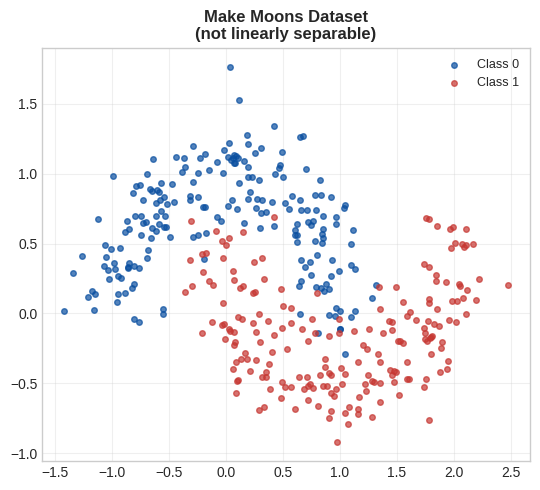

In [ ]:

# ── CELL 11: Generate Make Moons Dataset (from scratch) ──────────────────────

def make_moons(n_samples=300, noise=0.18, seed=42):
    """
    Two interleaved crescent moons — not linearly separable.
    Implemented from scratch (no sklearn).
    """
    rng  = np.random.RandomState(seed)
    n    = n_samples // 2
    th1  = np.linspace(0, np.pi, n)
    th2  = np.linspace(0, np.pi, n)

    moon1 = np.column_stack([np.cos(th1), np.sin(th1)])
    moon2 = np.column_stack([1 - np.cos(th2), 1 - np.sin(th2) - 0.5])

    X = np.vstack([moon1, moon2]) + rng.randn(n_samples, 2) * noise
    Y = np.hstack([np.zeros(n), np.ones(n)])
    return X, Y

X_data, Y_data = make_moons(n_samples=400, noise=0.20)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(X_data[Y_data==0, 0], X_data[Y_data==0, 1],
           s=16, c='#0A4FA0', alpha=0.7, label='Class 0')
ax.scatter(X_data[Y_data==1, 0], X_data[Y_data==1, 1],
           s=16, c='#C63732', alpha=0.7, label='Class 1')
ax.set_title("Make Moons Dataset\n(not linearly separable)", fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("moons_data.png", dpi=130, bbox_inches='tight')
plt.show()

# Reshape for our convention: (features, q_examples)
P_train = X_data.T           # shape: (2, 400)
T_train = Y_data.reshape(1, -1)  # shape: (1, 400)

In [ ]:
# ── CELL 12: Train the Network ───────────────────────────────────────────────

print("Training [2 -> 8 -> 8 -> 1] network on Make Moons:")
trained_params, loss_hist = train(
    P_train, T_train,
    layer_dims=[2, 8, 8, 1],
    lr=0.2,
    num_epochs=3000,
    loss_fn="mse",
    print_every=300,
    seed=42,
)
train_acc = accuracy(P_train, T_train, trained_params)
print(f"\n  Final Training Accuracy: {train_acc:.1f}%")

Training [2 -> 8 -> 8 -> 1] network on Make Moons:
  Epoch    0  |  MSE = 0.523653
  Epoch  300  |  MSE = 0.050508
  Epoch  600  |  MSE = 0.036156
  Epoch  900  |  MSE = 0.031232
  Epoch 1200  |  MSE = 0.028911
  Epoch 1500  |  MSE = 0.027573
  Epoch 1800  |  MSE = 0.026707
  Epoch 2100  |  MSE = 0.026104
  Epoch 2400  |  MSE = 0.025662
  Epoch 2700  |  MSE = 0.025323

  Final Training Accuracy: 97.5%


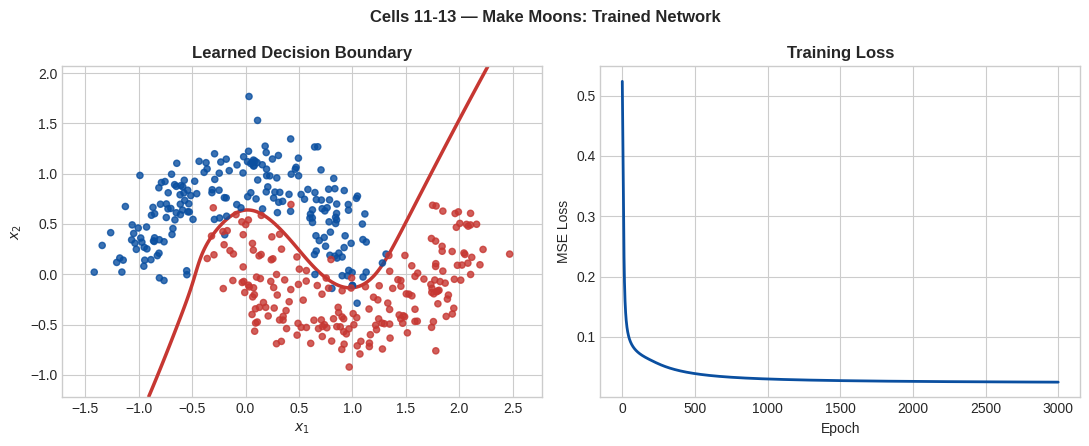

In [ ]:
# ── CELL 13: Visualise Decision Boundary ─────────────────────────────────────

def plot_decision_boundary(P, T, params, loss_hist, title="Decision Boundary"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.suptitle(title, fontweight="bold", fontsize=12)

    # ── Left: scatter + decision boundary line ─────────────────────────
    ax = axes[0]
    x_min, x_max = P[0].min() - 0.3, P[0].max() + 0.3
    y_min, y_max = P[1].min() - 0.3, P[1].max() + 0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                         np.linspace(y_min, y_max, 400))
    grid   = np.c_[xx.ravel(), yy.ravel()].T
    ZZ, _  = forward(grid, params)
    ZZ     = ZZ.reshape(xx.shape)


    ax.contour(xx, yy, ZZ, levels=[0.5], colors=["#C63732"], linewidths=2.5)

    colors = ["#0A4FA0" if t == 0 else "#C63732" for t in T[0]]
    ax.scatter(P[0], P[1], c=colors, s=20, alpha=0.8, zorder=5)
    ax.set_title("Learned Decision Boundary", fontweight="bold")
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")

    # ── Right: training loss curve ────────────────────────────────────────────
    axes[1].plot(loss_hist, color="#0A4FA0", lw=2)
    axes[1].set_title("Training Loss", fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MSE Loss")

    plt.tight_layout(); plt.show()

plot_decision_boundary(P_train, T_train, trained_params, loss_hist,
                       title="Cells 11-13 — Make Moons: Trained Network")

**SECTION 9: FINAL EXERCISE — YOUR TURN**

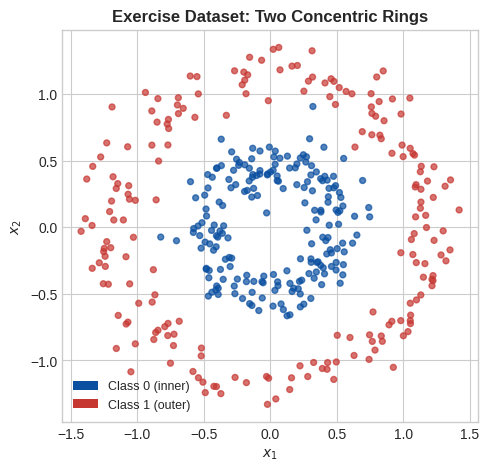

Dataset ready: P_ex.shape = (2, 400)   T_ex.shape = (1, 400)
Now train your own neural network to classify this dataset.


In [ ]:

# ── CELL 15: Exercise — Train Your Own Network ────────────────────────────────
"""
You have now built every component from scratch:
  init_params  →  forward  →  mse_loss  →  backward  →  train

Your exercise: use those tools to classify a new dataset.

Below is a simple 2-class dataset with 2 features (no sklearn needed).
Your tasks:

  TASK 1: Choose an architecture and train the network.
          Try: layer_dims = [2, ?, ?, 1]
          Choose the number of hidden neurons yourself.

  TASK 2: Print the final training accuracy.

  TASK 3 (stretch): Try at least two different architectures or learning rates.
          Which gives better accuracy? Why?

Everything you need is already defined above — init_params, forward,
mse_loss, backward, train, accuracy, predict.
"""

# ── Dataset: two concentric rings ────────────────────────────────────────────
# Inner ring = class 0, Outer ring = class 1
# No sklearn — generated entirely with NumPy trigonometry.

def make_rings(n_samples=300, noise=0.12, seed=42):
    """Two concentric rings — linearly inseparable."""
    rng = np.random.RandomState(seed)
    n   = n_samples // 2

    # Inner ring: radius ~0.5
    theta1 = rng.uniform(0, 2 * np.pi, n)
    r1     = rng.normal(0.5, noise, n)
    X_inner = np.c_[r1 * np.cos(theta1), r1 * np.sin(theta1)]

    # Outer ring: radius ~1.2
    theta2 = rng.uniform(0, 2 * np.pi, n)
    r2     = rng.normal(1.2, noise, n)
    X_outer = np.c_[r2 * np.cos(theta2), r2 * np.sin(theta2)]

    X = np.vstack([X_inner, X_outer])          # (n_samples, 2)
    Y = np.hstack([np.zeros(n), np.ones(n)])   # (n_samples,)
    idx = rng.permutation(n_samples)
    return X[idx].T, Y[idx].reshape(1, -1)     # shapes: (2, q), (1, q)

# Generate and visualise
P_ex, T_ex = make_rings(n_samples=400)

fig, ax = plt.subplots(figsize=(5, 5))
colors = ['#0A4FA0' if t == 0 else '#C63732' for t in T_ex[0]]
ax.scatter(P_ex[0], P_ex[1], c=colors, s=18, alpha=0.7)
ax.set_title('Exercise Dataset: Two Concentric Rings', fontweight='bold')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#0A4FA0', label='Class 0 (inner)'),
                   Patch(facecolor='#C63732', label='Class 1 (outer)')], fontsize=9)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()
print("Dataset ready: P_ex.shape =", P_ex.shape, "  T_ex.shape =", T_ex.shape)

print("Now train your own neural network to classify this dataset.")



In [ ]:
# ── YOUR CODE HERE ────────────────────────────────────────────────────────────
# Hint: use the train() function defined in Cell 10.
# train(P, T, layer_dims, lr, num_epochs) returns (params, history)
#
# Example to get you started (but try your own settings!):
#
#   trained_params, loss_hist = train(
#       P_ex, T_ex,
#       layer_dims = [2, ???, ???, 1],  # choose your architecture
#       lr         = ???,               # choose your learning rate
#       num_epochs = ???)               # choose how many epochs
#
#   print("Final accuracy:", accuracy(P_ex, T_ex, trained_params), "%")
#
# To plot the decision boundary once trained:
#   plot_decision_boundary(P_ex, T_ex, trained_params, loss_hist,
#                          title="My Network — Concentric Rings")

# ▼▼▼ Write your code below ▼▼▼
